## Part 1: Upload the Libraries we will be using and assign aliases

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from datetime import datetime, date, time, timedelta
import plotly.express as px


## Part 2: Import the data and take an overview of what kind of data is in each column

In [22]:
# Download the data from DBeaver as a CSV file.

df = pd.read_csv('./data/dataset.csv')

#Let's check if that has worked by getting an overall view

df.head()


,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,7129300520,3.0,1.00,1180.0,5650.0,1.0,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,6414100192,3.0,2.25,2570.0,7242.0,2.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,5631500400,2.0,1.00,770.0,10000.0,1.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,2487200875,4.0,3.00,1960.0,5000.0,1.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,1954400510,3.0,2.00,1680.0,8080.0,1.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


In [23]:
#let's see how many rows & columns

print(df.shape)

#Lets view the column names

print('\n', df.columns)

#Now we can use the '.head()' function to view the columns omitted from the general view

print('\n', df[['waterfront', 'view', 'condition']].head(16))

(21597, 23)

 Index(['date', 'price', 'house_id', 'id', 'id.1', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

     waterfront  view  condition
0          NaN   0.0          3
1          0.0   0.0          3
2          0.0   0.0          3
3          0.0   0.0          5
4          0.0   0.0          3
5          0.0   0.0          3
6          0.0   0.0          3
7          0.0   NaN          3
8          0.0   0.0          3
9          0.0   0.0          3
10         NaN   0.0          3
11         0.0   0.0          4
12         0.0   0.0          4
13         0.0   0.0          4
14         0.0   0.0          3
15         0.0   3.0          3


## Part 3: Selecting & Cleaning the Data will be useful for Amy requests

#### After discussion with the team we selected the following:

 price ; house_id ; bedrooms ; bathrooms ; sqft_living ; sqft_lot ; floors ; waterfront ; view ; condition ; grade ; zipcode ; lat ; long

In [24]:
#Make a copy of the dataset

df_cop = df.copy()

df_cop.head()

,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,7129300520,3.0,1.00,1180.0,5650.0,1.0,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,6414100192,3.0,2.25,2570.0,7242.0,2.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,5631500400,2.0,1.00,770.0,10000.0,1.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,2487200875,4.0,3.00,1960.0,5000.0,1.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,1954400510,3.0,2.00,1680.0,8080.0,1.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


In [25]:
#Remove unnecessary columns via the '.drop' function. 
## First lets list the columns again. This will help me numerate those columns I want to drop.

print(df_cop.columns)

# From this I can see the integer positions of the columns I want to drop and I will apply these changes:

df_cop = df_cop.drop(df_cop.columns[[3, 4, 14, 15, 16, 17, 21, 22]], axis=1)

print('\n', df_cop.head())

Index(['date', 'price', 'house_id', 'id', 'id.1', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

          date     price    house_id  bedrooms  bathrooms  sqft_living  \
0  2014-10-13  221900.0  7129300520       3.0       1.00       1180.0   
1  2014-12-09  538000.0  6414100192       3.0       2.25       2570.0   
2  2015-02-25  180000.0  5631500400       2.0       1.00        770.0   
3  2014-12-09  604000.0  2487200875       4.0       3.00       1960.0   
4  2015-02-18  510000.0  1954400510       3.0       2.00       1680.0   

   sqft_lot  floors  waterfront  view  condition  grade  zipcode      lat  \
0    5650.0     1.0         NaN   0.0          3      7    98178  47.5112   
1    7242.0     2.0         0.0   0.0          3      7    98125  47.7210   
2   10000.0    

In [26]:
# Let's now check what is each datatype of all those columns we have kept
 
df_cop.dtypes

date               str
price          float64
house_id         int64
bedrooms       float64
bathrooms      float64
sqft_living    float64
sqft_lot       float64
floors         float64
waterfront     float64
view           float64
condition        int64
grade            int64
zipcode          int64
lat            float64
long           float64
dtype: object

In [27]:
# Let's also verify how many 'NaN's there are per column:

df_cop.isna().sum()

date              0
price             0
house_id          0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront     2391
view             63
condition         0
grade             0
zipcode           0
lat               0
long              0
dtype: int64

## Part 3: Cleaning 'date'

In [28]:
# Let's change the date from strings by parsing them into datetime

df_cop["date"] = pd.to_datetime(df_cop["date"])

df_cop['date'].head()

0   2014-10-13
1   2014-12-09
2   2015-02-25
3   2014-12-09
4   2015-02-18
Name: date, dtype: datetime64[us]

## Part 4: Cleaning 'price'; 'bedroom'; 'sqft_living' & 'sqft_lot'

In [29]:
# For this I want to change the datatype of these columns from a float to an integer. 

print(df_cop[['price', 'bedrooms', 'sqft_living', 'sqft_lot']].dtypes)

## We already know from the 'isna().sum()' function we ran earlier that there is no NaN values in the these columns
## We can assume there are no tenths in the 'bedrooms' column but let's double-check quickly

print('\n', df_cop['bedrooms'].value_counts())

# Since the others will contain a lot of different values, we should check if there are any entries where the modulo != 0

price_list = df_cop['price'].tolist()
vlist = []

for x in range(len('price_list')):
    if x % 1 != 0:
        vlist.append(x)

liv_list = df_cop['sqft_living'].tolist()
vvlist = []

for x in range(len('sqft_living')):
    if x % 1 != 0:
        vvlist.append(x)


lot_list = df_cop['sqft_lot'].tolist()
vvvlist = []

for x in range(len('sqft_lot')):
    if x % 1 != 0:
        vvvlist.append(x)

print('\n', [vlist, vvlist, vvvlist])

# Now that we have certified there are not 'NaN's' nor modulo values, we can change the dataset from floats to integers

cols = ['price', 'bedrooms', 'sqft_living', 'sqft_lot']
df_cop[cols] = df_cop[cols].astype(int)

price          float64
bedrooms       float64
sqft_living    float64
sqft_lot       float64
dtype: object

 bedrooms
3.0     9824
4.0     6882
2.0     2760
5.0     1601
6.0      272
1.0      196
7.0       38
8.0       13
9.0        6
10.0       3
11.0       1
33.0       1
Name: count, dtype: int64

 [[], [], []]


In [30]:
df_cop.head()

,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,zipcode,lat,long
0,2014-10-13,221900,7129300520,3,1.00,1180,5650,1.0,NaN,0.0,3,7,98178,47.5112,-122.257
1,2014-12-09,538000,6414100192,3,2.25,2570,7242,2.0,0.0,0.0,3,7,98125,47.7210,-122.319
2,2015-02-25,180000,5631500400,2,1.00,770,10000,1.0,0.0,0.0,3,6,98028,47.7379,-122.233
3,2014-12-09,604000,2487200875,4,3.00,1960,5000,1.0,0.0,0.0,5,7,98136,47.5208,-122.393
4,2015-02-18,510000,1954400510,3,2.00,1680,8080,1.0,0.0,0.0,3,8,98074,47.6168,-122.045


## Part 5: cleaning 'house_id'

In [31]:
# Given that the duplicates datatype is an integer (int64), I want to see if there are duplicate entries for 'house_id'
# This is important so we don't have 2 different sets of data for one house

print(df_cop['house_id'].duplicated().value_counts())


## Since there are only 177 duplicates, I believe these are caused due to the same house being sold at different dates.
## Let's verify this

dupdatcheck = df_cop[df_cop['house_id'].duplicated(keep=False)].sort_values(['house_id', 'date'], ascending=[True, False])

print('\n', dupdatcheck.iloc[:6, np.r_[:3]])

### Let's go ahead and remove the "older" entries and check they have been removed correctly

df_cop = df_cop.sort_values('date').drop_duplicates(subset='house_id', keep='last')

df_cop.sort_values(['house_id']).iloc[:10, np.r_[:3]]


house_id
False    21420
True       177
Name: count, dtype: int64

             date   price   house_id
2495  2015-04-22  300000    1000102
2494  2014-09-16  280000    1000102
16801 2015-04-24  175000    7200179
16800 2014-10-16  150000    7200179
11422 2014-10-20  250000  109200390
11421 2014-08-20  245000  109200390


,date,price,house_id
2495,2015-04-22,300000,1000102
6729,2014-05-08,647500,1200019
8404,2014-08-11,400000,1200021
8800,2015-04-01,235000,2800031
3553,2015-03-19,402500,3600057
18506,2015-03-30,680000,3600072
3197,2015-02-24,178000,3800008
21047,2014-07-09,487000,5200087
4329,2014-11-12,281000,6200017
16701,2014-11-04,239000,7200080


## Part 6: "Cleaning" 'bathrooms' & 'floors'

In [32]:
#Initially we were going to use the '.round(0)' function to round all these numbers up and turn them to integers.
## However, upon some real estate research, we learned this is intentional and is an indicator of the contents of each bathroom:

<img src="https://danmccurley.com/wp-content/uploads/bathroom-infographic-1024x1024.png" alt="drawing" style="width:450px;"/>



In [33]:
#Something similar can help to explain why here are some entries with 1.5 for 'floors' e.g. Bungalows

## Let's see what the most common bathroom set-ups and floors are:

print(df_cop['bathrooms'].value_counts().head())

print('\n', df_cop['floors'].value_counts())

# We will therefore not be changing these values

bathrooms
2.50    5352
1.00    3794
1.75    3020
2.25    2031
2.00    1913
Name: count, dtype: int64

 floors
1.0    10552
2.0     8203
1.5     1888
3.0      609
2.5      161
3.5        7
Name: count, dtype: int64


In [34]:
# I am not dealing with the NaNs for the time being given the fact there is so few entries compared to the siz of the list. 
# I will see if they show up later

df_cop[['waterfront', 'view']].isna().sum()

waterfront    2360
view            63
dtype: int64

## Part 7: Rearranging the columns & indexing 'house_id'

In [35]:
# Let's now rearrange the columns in order of importance:

cols2 = ['price', 'grade', 'condition', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'waterfront', 'zipcode', 'lat', 'long', 'date', 'house_id']

# Now let's index 'house_id' and remove the 'house_id' as a column:

df_cop = df_cop.loc[:, cols2].set_index('house_id')

df_cop.head()


,price,grade,condition,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,waterfront,zipcode,lat,long,date
house_id,,,,,,,,,,,,,,
2202500290,435000,7,4,4,1.0,1450,8800,1.0,0.0,0.0,98006,47.5746,-122.135,2014-05-02
7853361370,555000,8,3,4,2.5,3310,6500,2.0,0.0,0.0,98065,47.5150,-121.870,2014-05-02
7197300105,550000,7,4,4,2.5,1940,10500,1.0,0.0,NaN,98052,47.6830,-122.114,2014-05-02
3438501320,295000,7,3,2,2.5,1630,1368,2.0,0.0,0.0,98106,47.5489,-122.363,2014-05-02
472000620,790000,9,4,3,2.5,2600,4750,1.0,0.0,0.0,98117,47.6833,-122.400,2014-05-02


## Part 8: Creating our 'Average' list

I am focussing on Amy's 'buying' requirements: "...needs average outskirt houses over time to hide from the FBI"

The first thing from this statement that needs to be taken into consideration is the word "average". After asking Amy this she confirmed that this meant both in terms of price AND in terms of house quality in accordance to real-estate ratings.

In [ ]:
# I now wanted to get a quick view at the data of the columns I want to find the "average" for by checking mean, max and min

df_cop.describe().round(0)

,price,grade,condition,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,waterfront,zipcode,lat,long,date
count,21420.0,21420.0,21420.0,21420.0,21420.0,21420.0,21420.0,21420.0,21357.0,19060.0,21420.0,21420.0,21420.0,21420
mean,541861.0,8.0,3.0,3.0,2.0,2083.0,15128.0,1.0,0.0,0.0,98078.0,48.0,-122.0,2014-10-29 17:13:04.537815
min,78000.0,3.0,1.0,1.0,0.0,370.0,520.0,1.0,0.0,0.0,98001.0,47.0,-123.0,2014-05-02 00:00:00
25%,324950.0,7.0,3.0,3.0,2.0,1430.0,5040.0,1.0,0.0,0.0,98033.0,47.0,-122.0,2014-07-22 00:00:00
50%,450550.0,7.0,3.0,3.0,2.0,1920.0,7614.0,2.0,0.0,0.0,98065.0,48.0,-122.0,2014-10-17 00:00:00
75%,645000.0,8.0,4.0,4.0,2.0,2550.0,10690.0,2.0,0.0,0.0,98117.0,48.0,-122.0,2015-02-18 00:00:00
max,7700000.0,13.0,5.0,33.0,8.0,13540.0,1651359.0,4.0,4.0,1.0,98199.0,48.0,-121.0,2015-05-27 00:00:00
std,367557.0,1.0,1.0,1.0,1.0,919.0,41531.0,1.0,1.0,0.0,53.0,0.0,0.0,NaN


In [37]:
# Now time to filter the data:

df_avg = df_cop.query(
    "grade == 7 and condition == 3 and bedrooms == 3 and bathrooms == 2 and floors == 1 and view == 0 and waterfront == 0"
).copy()

## Let's look at the data again

df_avg.describe().round(0)


,price,grade,condition,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,waterfront,zipcode,lat,long,date
count,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228
mean,348750.0,7.0,3.0,3.0,2.0,1537.0,15337.0,1.0,0.0,0.0,98059.0,48.0,-122.0,2014-10-26 10:44:12.631579
min,158000.0,7.0,3.0,3.0,2.0,930.0,2159.0,1.0,0.0,0.0,98001.0,47.0,-122.0,2014-05-05 00:00:00
25%,253076.0,7.0,3.0,3.0,2.0,1328.0,6500.0,1.0,0.0,0.0,98027.0,47.0,-122.0,2014-07-23 12:00:00
50%,315250.0,7.0,3.0,3.0,2.0,1495.0,8087.0,1.0,0.0,0.0,98042.0,47.0,-122.0,2014-10-16 12:00:00
75%,428250.0,7.0,3.0,3.0,2.0,1680.0,11180.0,1.0,0.0,0.0,98092.0,48.0,-122.0,2015-02-05 12:00:00
max,810000.0,7.0,3.0,3.0,2.0,2800.0,222156.0,1.0,0.0,0.0,98199.0,48.0,-122.0,2015-05-07 00:00:00
std,115879.0,0.0,0.0,0.0,0.0,294.0,32223.0,0.0,0.0,0.0,47.0,0.0,0.0,NaN


In [38]:
#Let's make a separate list removing the shared "average" values

df_mini = df_avg.drop(df_avg.columns[[1, 2, 3, 4, 7, 8, 9]], axis=1)

df_mini.head()

,price,sqft_living,sqft_lot,zipcode,lat,long,date
house_id,,,,,,,
1402810140,300000,1050,10072,98019,47.7341,-121.976,2014-05-05
7697870530,239900,1410,7566,98030,47.3674,-122.182,2014-05-07
2473100635,297950,1240,10800,98058,47.4490,-122.155,2014-05-08
1926069054,450000,1510,43560,98077,47.7218,-122.079,2014-05-08
1232000915,481450,1410,4800,98117,47.6852,-122.378,2014-05-09


## Part 9: Creating the "Top 10%" list

In [39]:
#Let's find out the top 10% lux_thr = df_cop['price'].quantile(0.90)

top10 = df_cop['price'].quantile(0.90)

df_t10 = df_cop[df_cop['price'] >= top10]

## Let's look at the data again

df_lux = df_cop.sort_values(['price', 'grade', 'condition'], ascending=False)

df_lux.head(20)

,price,grade,condition,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,waterfront,zipcode,lat,long,date
house_id,,,,,,,,,,,,,,
6762700020,7700000,13,4,6,8.00,12050,27600,2.5,3.0,0.0,98102,47.6298,-122.323,2014-10-13
9808700762,7060000,11,3,5,4.50,10040,37325,2.0,2.0,1.0,98004,47.6500,-122.214,2014-06-11
9208900037,6890000,13,3,6,7.75,9890,31374,2.0,4.0,0.0,98039,47.6305,-122.240,2014-09-19
2470100110,5570000,13,3,5,5.75,9200,35069,2.0,0.0,0.0,98039,47.6289,-122.233,2014-08-04
8907500070,5350000,12,3,5,5.00,8000,23985,2.0,4.0,0.0,98004,47.6232,-122.220,2015-04-13
7558700030,5300000,12,4,6,6.00,7390,24829,2.0,NaN,1.0,98040,47.5631,-122.210,2015-04-13
1247600105,5110000,12,3,5,5.25,8010,45517,2.0,4.0,1.0,98033,47.6767,-122.211,2014-10-20
1924059029,4670000,12,3,5,6.75,9640,13068,1.0,4.0,1.0,98040,47.5570,-122.210,2014-06-17
7738500731,4500000,12,3,5,5.50,6640,40014,2.0,4.0,1.0,98155,47.7493,-122.280,2014-08-15


## Part 10: Visualizing the data

With the filtered data above we have a list of all houses that meet the real-estate determination of "average"

From this we can first take a look at how the price of these houses is distributed. By doing this we can find those "average" houses that are "averagely" priced

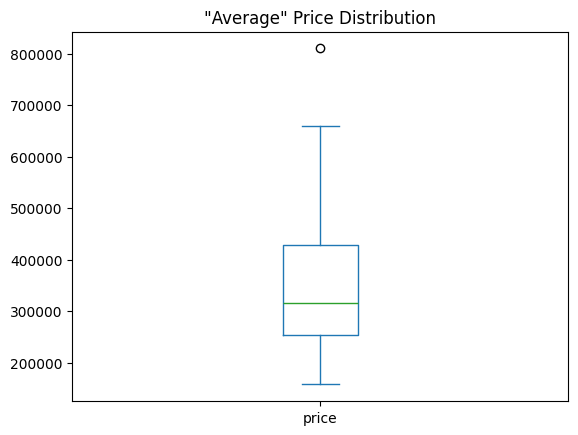

In [40]:
# Let's get an overall view on the "Average" price distribution

df_mini['price'].plot(kind='box', title='"Average" Price Distribution')
plt.show()

From this we can use the interquartile range to establish the price of average-priced, average houses. 

Given that Amy is a mafiosi we can assume money is not an option but rather she is seeking "average" housing to "blend in" and not draw attention. Therefore, this graph illustrates the price range of average housing. I would recommend to Amy to focus on those within the IQR so as to truly have a middle of the road housing.

Now that we have established those houses that fit the "average" criteria, we can move onto locating these on a map to determine if they are in the "outskirts"

We are going to do that by first seeing what the areas of King County are like in terms of the price range and number of "average" houses each zipcode has

In [ ]:
# Firstly, let's a variable for the outlier so we can locate this house on the map later

df_out = df_mini[(df_mini['price'] > 700000)]

df_out

,price,sqft_living,sqft_lot,zipcode,lat,long,date
house_id,,,,,,,
2025059134,810000,1760,16928,98004,47.6363,-122.202,2015-01-13


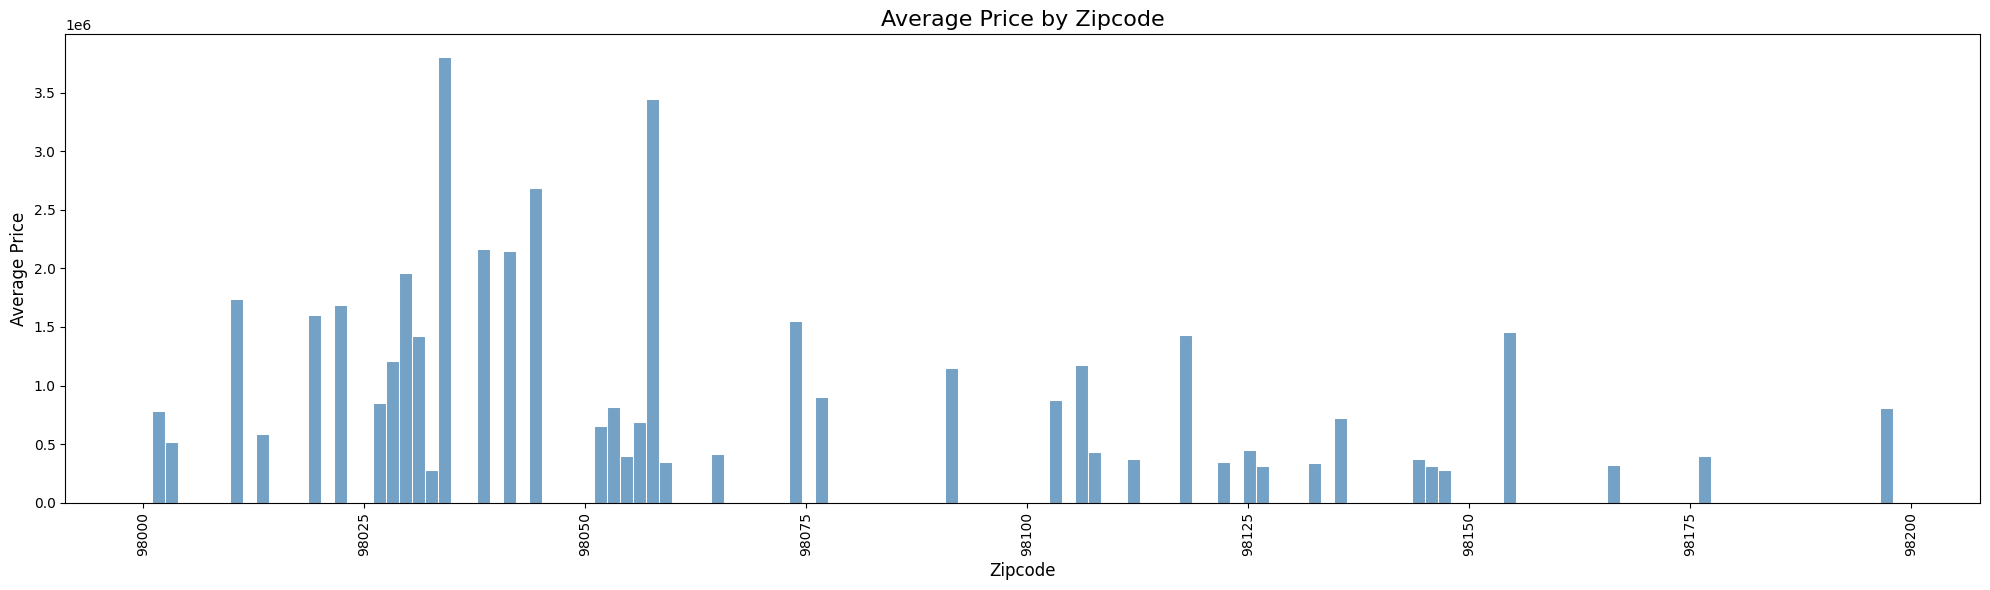

In [42]:
#Filtering the data to only include those properties with an "average" price range (Q1:Q3)

df_avmin = df_mini[(df_mini['price'] <= 450000) & (df_mini['price'] >= 250000)]

df_avmin = df_avmin.sort_values(['price', 'sqft_living', 'sqft_lot'], ascending=False)

# Plotting this dataset onto a histogram to see what areas have the more pricier average properties

plt.figure(figsize=(20, 6))
sns.histplot(
    data=df_avmin.reset_index(),
    x='zipcode',
    weights='price',
    bins=len(df_avmin),
    color='steelblue',
    edgecolor='white'
)
plt.title('Average Price by Zipcode', fontsize=16)
plt.xlabel('Zipcode', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


This graph helps us identify which areas in King County have the most "average" houses.  From looking up the zipcodes we can see that the vast majority of these types of houses are indeed located in the outskirts.

From this, for example, I could make a suggestion to Amy that she should focus on those houses in and around the 98025 zipcode i.e. the MAPLE VALLEY area because it has the most but also a big variety of price ranges (especially if Amy would still like the more high end of average)

However, it would be good to see a graph that shows us how many "average" houses they have and how they are split price-wise. To do that we can first plot a bar chart and then a scatter map. This will give us great insight into what areas would be best for Amy.

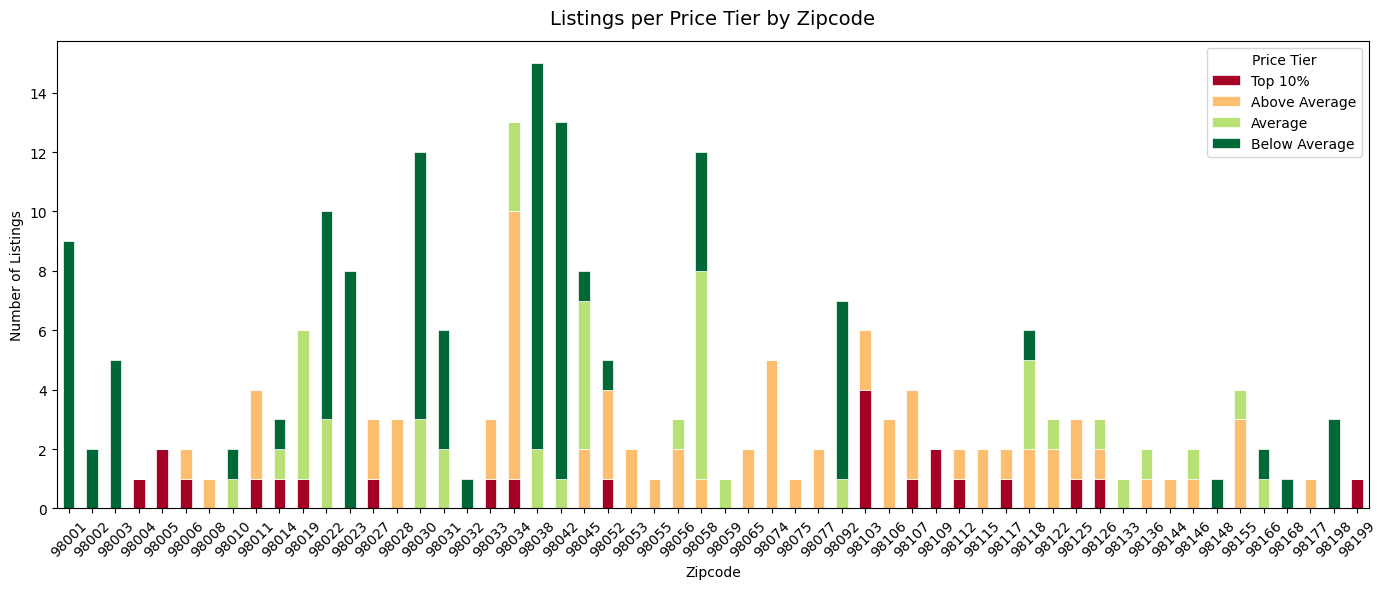

In [ ]:
# Visualizing the data as a bar chart. First I need to create the price parameters:

p90 = df_avg['price'].quantile(0.90)
p60 = df_avg['price'].quantile(0.60)
p40 = df_avg['price'].quantile(0.40)

df_t10 = df_avg[df_avg['price'] >= p90]
df_abv = df_avg[(df_avg['price'] <= p90) & (df_avg['price'] >= p60)]
df_mid = df_avg[(df_avg['price'] <= p60) & (df_avg['price'] >= p40)]
df_bel = df_avg[df_avg['price'] <= p40]

# Now to build a new, combined DataFrame with counts per zipcode per tier
tiers = {
    'Top 10%':  df_t10['zipcode'].value_counts(),
    'Above Average': df_abv['zipcode'].value_counts(),
    'Average':       df_mid['zipcode'].value_counts(),
    'Below Average': df_bel['zipcode'].value_counts(),
}


df_tiers = pd.DataFrame(tiers)

# Fill NaN values with 0 (since a missing zip code means 0 occurrences in that tier)
df_tiers = df_tiers.fillna(0).astype(int)

df_pct = df_tiers.div(df_tiers.sum(axis=1), axis=0) * 100

# Now let's visualize this as a bar graph:

dfg = df_tiers.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='RdYlGn',
    edgecolor='white',
    linewidth=0.5,
)

dfg.set_title('Listings per Price Tier by Zipcode', fontsize=14, pad=12)
dfg.set_xlabel('Zipcode')
dfg.set_ylabel('Number of Listings')
dfg.legend(title='Price Tier', loc='upper right')
dfg.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


This graph gives us a better visual insight into what each zipcode offers in terms of average housing.

This can allow Amy to think about what neighbourhood would she prefer to be in when "hiding out". Would it be more beneficial to her to be in an area where there are more houses that are above average, or below?

I would recommend trying to choose an outskirt area that has mainly 'average# housing with some just above and some just below. An example of this is another zipcode in the Maple Valley/Maple Heights region (98058)

It would be best for Amy though if she can see this on a map for reference. So let's visualize the data as a scatter graph:

In [ ]:

# Let's first create a new "price tier" column so we can define our houses into the  4 categories listed above

def assign_color(price):
    if price == 810000:
        return 'Outlier'
    elif price >= p90:
        return 'Top 10%'
    elif p60 <= price <= p90:
        return 'Above Average'
    elif p40 <= price <= p60:
        return 'Average'
    else:
        return 'Below Average'

df_avg['price_tier'] = df_avg['price'].apply(assign_color)

# Let's now plot the graph

map = px.scatter_map(
    df_avg,
    lat="lat",
    lon="long",
    hover_name="price",
    color="price_tier",
    color_discrete_map={
        "Top 10%":               "red",
        "Above Average":         "orange",
        "Average":               "chartreuse",
        "Below Average":         "green",
        "Outlier":               "cyan"
    },
    zoom=9,
    height=500
)

map.update_layout(map_style="open-street-map")
map.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
map.show()


## Insights

- There are more affordable "average" housing in the outskirts vs centrally
- The more southern and centrally located the house also affects the type of house in regards to our "average" qualifiers as well as price

## Recommendations

Based on all the data we have acquired and shown to Amy, my recommendations for where she should look to purchase "hideout" housing are

1. Covington / Maple Valley:
- Pros = lots of average priced & below average priced housing; not too far away from central; similar neighbouring areas if you needed to move somewhere closeby in a hurry
- Cons = mainly below average housing (Is that a favorable community for Amy due to status and potential known affiliations), not as secluded and in the "outskirts" as others

2. North Bend / Snoqualmie
- Pros = A good amount an a majority of the "Average" priced houses, very secluded (surrounded by lots of forest) and yet easy to access the centre due to being near the motorway
- Cons = More above average houses show up in this area than MV. Being closer to central might be problematic for Amy's anonymity 

3. Enumclaw
- Pros = Very far in the outskirts, away from the central, lowest of the 3 in terms of mostly finding "below average" priced housing there
- Cons = Same as Pros, what can be good can also be bad depending on what Amy wants from her hideout houses